In [2]:
### Importation des modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn import decomposition
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

### 2.1 - Chargement des données

In [3]:
data_true = pd.read_csv("data.csv")
print("Colonnes du dataset :\n", data_true.columns)
print("..............................................................")
print("On affiche quelques lignes du dataset :\n", data_true.head())
print("..............................................................")
print("Dimension des données :\n", data_true.shape)

Colonnes du dataset :
 Index(['Catalog', 'HIP', 'Proxy', 'RAhms', 'DEdms', 'Vmag', 'VarFlag',
       'r_Vmag', 'RAdeg', 'DEdeg', 'AstroRef', 'Plx', 'pmRA', 'pmDE',
       'e_RAdeg', 'e_DEdeg', 'e_Plx', 'e_pmRA', 'e_pmDE', 'DE:RA', 'Plx:RA',
       'Plx:DE', 'pmRA:RA', 'pmRA:DE', 'pmRA:Plx', 'pmDE:RA', 'pmDE:DE',
       'pmDE:Plx', 'pmDE:pmRA', 'F1', 'F2', '---', 'BTmag', 'e_BTmag', 'VTmag',
       'e_VTmag', 'm_BTmag', 'B-V', 'e_B-V', 'r_B-V', 'V-I', 'e_V-I', 'r_V-I',
       'CombMag', 'Hpmag', 'e_Hpmag', 'Hpscat', 'o_Hpmag', 'm_Hpmag', 'Hpmax',
       'HPmin', 'Period', 'HvarType', 'moreVar', 'morePhoto', 'CCDM', 'n_CCDM',
       'Nsys', 'Ncomp', 'MultFlag', 'Source', 'Qual', 'm_HIP', 'theta', 'rho',
       'e_rho', 'dHp', 'e_dHp', 'Survey', 'Chart', 'Notes', 'HD', 'BD', 'CoD',
       'CPD', '(V-I)red', 'SpType', 'r_SpType'],
      dtype='object')
..............................................................
On affiche quelques lignes du dataset :
   Catalog  HIP Proxy        RAhms  

Le dataset est constituées de données sur 118 218 étoiles et de 78 colonnes. Plusieurs de ces colonnes ne nous seront pas utiles.

### 2.2 - Visualisation des données

In [4]:
# Types de chaque colonne
print(data_true.dtypes)

Catalog      object
HIP           int64
Proxy        object
RAhms        object
DEdms        object
             ...   
CoD          object
CPD          object
(V-I)red    float64
SpType       object
r_SpType     object
Length: 78, dtype: object


In [7]:
# Extraire seulement les données numériques
num_data = data_true.select_dtypes(include=['number'])

# Matrice de corrélation
corr_matrix = num_data.corr()
print(corr_matrix)

#plt.figure(figsize=(20, 20))
#sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
#plt.title(r"Matrice de Corrélation des Variables Numériques")
#plt.show()

                HIP      Vmag   VarFlag     RAdeg     DEdeg       Plx  \
HIP        1.000000  0.003751  0.022815  0.999513 -0.003517 -0.002868   
Vmag       0.003751  1.000000  0.441254  0.002829 -0.007384 -0.054949   
VarFlag    0.022815  0.441254  1.000000  0.022740  0.020087 -0.087664   
RAdeg      0.999513  0.002829  0.022740  1.000000 -0.003610 -0.003073   
DEdeg     -0.003517 -0.007384  0.020087 -0.003610  1.000000  0.001103   
Plx       -0.002868 -0.054949 -0.087664 -0.003073  0.001103  1.000000   
pmRA      -0.032329 -0.001165  0.008165 -0.032885  0.001581  0.008910   
pmDE      -0.012362 -0.051399  0.002665 -0.012239 -0.013896 -0.209806   
e_RAdeg    0.005589  0.186133  0.219122  0.004837 -0.006926  0.078872   
e_DEdeg    0.005067  0.187942  0.222543  0.004202 -0.010726  0.074768   
e_Plx      0.003545  0.324266  0.234460  0.002937 -0.009046  0.118504   
e_pmRA     0.007956  0.260811  0.212447  0.007012 -0.007746  0.114305   
e_pmDE    -0.000127  0.278234  0.236816 -0.001111 -

In [8]:
# Extraire quelques données qui semblent être pertinentes (pour une meilleure visualisation)

def matrice_corr(sub_data_name, data) :
    num_data = data.select_dtypes(include=['number'])
    sub_data = num_data[sub_data_name]
    corr_matrix_sub = sub_data.corr()
    print(corr_matrix_sub)

    plt.figure(figsize=(10, 7))
    sns.heatmap(corr_matrix_sub, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
    plt.title("Matrice de Corrélation")
    plt.show()

#matrice_corr(['HIP', 'Vmag', 'Plx', 'B-V'], data_true)  



In [9]:
data_sub = data_true[['HIP', 'Vmag', 'Plx', 'B-V']]
#sns.pairplot(data=data_sub)  

### 2.4 - Sélection et créations de variables d'entrainement pertinentes 


In [10]:
# Sélection des variables pertinentes 
data = data_true[['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']]

# Filtrer les étoiles avec une parallaxe positive 
data = data[data['Plx'] > 0]

# Calcul de la distance (en pc) 
data['Distance'] = 1/data['Plx'] * 1000  

# Calcul de la magnitude absolue 
data['AbsoluteMag'] = data['Vmag'] - 5 * np.log10(data['Distance'] / 10)   

# Fonction pour calculer la température effective des étoiles
def bv_to_temp(bv):
    return 4600 * ((1 / (0.92 * bv + 1.7)) + (1 / (0.92 * bv + 0.62)))

# Ajouter la température aux données
data['Temperature'] = bv_to_temp(data['B-V'])


Le type spectral est une variable catégorielle qui doit être convertie en une forme utilisable par un algorithme de clustering : 
(O, B, A, F, G, K, M) ---> (1, 2, 3, ...)

In [11]:
# Encodage du type spectral
encoder = LabelEncoder()
data['SpType_encoded'] = encoder.fit_transform(data['SpType'])

# Supression du type spectral 
data = data.drop(columns=['SpType'])

### 2.3 - Traitement des données manquantes

In [12]:
# Vérfifier les valeurs manquantes 
missing_data = data.isnull()
nb_missing_value = missing_data.sum()    # Nombre de valeurs manquantes par colonne
print(nb_missing_value)


HIP                 0
Vmag                0
Plx                 0
B-V               887
Distance            0
AbsoluteMag         0
Temperature       887
SpType_encoded      0
dtype: int64


In [13]:
# Afficher le pourcentage de valeurs manquantes
missing_percent = missing_data.mean() * 100
print(missing_percent)

HIP               0.000000
Vmag              0.000000
Plx               0.000000
B-V               0.780055
Distance          0.000000
AbsoluteMag       0.000000
Temperature       0.780055
SpType_encoded    0.000000
dtype: float64


In [15]:
# Heatmap des valeurs manquantes
#plt.figure(figsize=(10, 6))
#sns.heatmap(data.isnull(), cmap="viridis")
#plt.title("Visualisation des valeurs manquantes")
#plt.show()

In [16]:
# Traiter les valeurs manquantes : comme on a énormément de données, on peut supprimer les lignes avec les valeurs manquantes dans les colonnes pertinentes 
data_clean = data.dropna(subset=['HIP', 'Vmag', 'Plx', 'B-V', 'Distance', 'AbsoluteMag', 'Temperature', 'SpType_encoded'])
print(data_clean.shape)


(112823, 8)


In [17]:
X = data_clean
X

,HIP,Vmag,Plx,B-V,Distance,AbsoluteMag,Temperature,SpType_encoded
0,1,9.10,3.54,0.482,282.485876,1.845016,6471.667826,1809
1,2,9.27,21.90,0.999,45.662100,5.972221,4745.140425,3178
2,3,6.61,2.81,-0.019,355.871886,-1.146468,10368.595588,1353
3,4,8.06,7.75,0.370,129.032258,2.506509,7044.130880,1604
4,5,8.55,2.87,0.902,348.432056,0.839409,4991.060700,2649
...,...,...,...,...,...,...,...,...
118213,118318,6.99,1.92,1.595,520.833333,-1.593494,3655.993639,3015
118214,118319,8.23,10.63,0.639,94.073377,3.362666,5818.920292,2296
118215,118320,7.59,5.00,0.999,200.000000,1.084850,4745.140425,2768
118216,118321,9.20,19.22,0.698,52.029136,5.618767,5608.544902,2470


### 2.5 - Vérification de nouvelles variables 


                Distance  AbsoluteMag  Temperature  SpType_encoded       B-V
Distance        1.000000     -0.33716    -0.003166        0.015183  0.034706
AbsoluteMag    -0.337160      1.00000    -0.112810        0.120800 -0.054170
Temperature    -0.003166     -0.11281     1.000000       -0.806002 -0.930123
SpType_encoded  0.015183      0.12080    -0.806002        1.000000  0.826801
B-V             0.034706     -0.05417    -0.930123        0.826801  1.000000


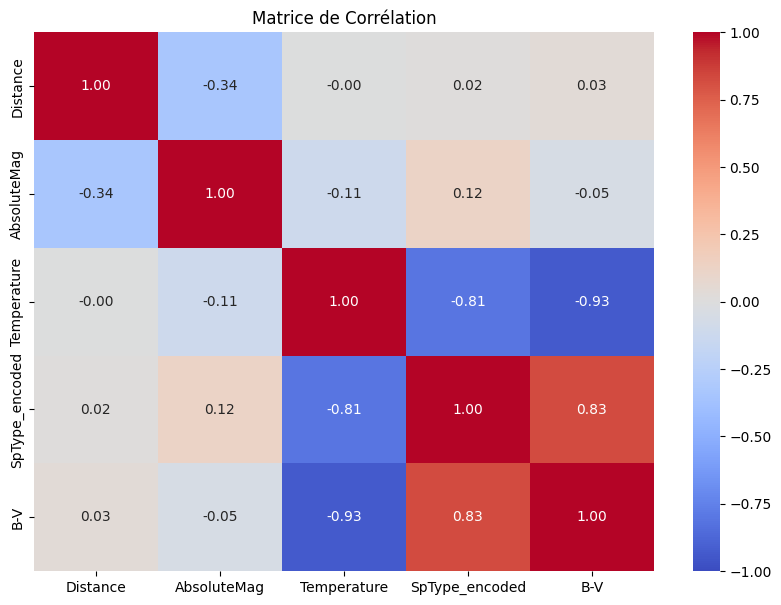

In [18]:
matrice_corr(['Distance', 'AbsoluteMag', 'Temperature', 'SpType_encoded', 'B-V'], data)

### 2.6 - Normalisation des variables d'entrainement 

Plusieurs méthodes existent pour normaliser les données.

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
X_scaled_df

,HIP,Vmag,Plx,B-V,Distance,AbsoluteMag,Temperature,SpType_encoded
0,-1.727453,0.618564,-0.352599,-0.454175,-0.073805,0.074351,0.130850,-0.227177
1,-1.727424,0.751857,1.280499,0.615606,-0.176107,1.801635,-0.713214,1.115105
2,-1.727394,-1.333777,-0.417532,-1.490848,-0.042104,-1.177621,2.035976,-0.674277
3,-1.727365,-0.196871,0.021875,-0.685926,-0.140093,0.351193,0.410715,-0.428176
4,-1.727336,0.187324,-0.412195,0.414893,-0.045318,-0.346508,-0.592988,0.596429
...,...,...,...,...,...,...,...,...
112818,1.731239,-1.035829,-0.496696,1.848854,0.029155,-1.364707,-1.245675,0.955286
112819,1.731268,-0.063579,0.278047,-0.129309,-0.155194,0.709505,-0.188265,0.250319
112820,1.731297,-0.565385,-0.222734,0.615606,-0.109437,-0.243788,-0.713214,0.713107
112821,1.731326,0.696971,1.042117,-0.007226,-0.173356,1.653710,-0.291113,0.420923


In [ ]:
# On affiche le dataset initial (sans aucune modification)
data_true
## On calcule les 3 grandeurs dans data_pca_calcul afin de les utiliser pour la pca

# Copie pour éviter de modifier directement le dataset initial
data_pca_calcul = data_true.copy()

# Filtrer les étoiles avec une parallaxe positive 
data_pca_calcul = data_pca_calcul[data_pca_calcul['Plx'] > 0]

# Calcul de la distance (en pc) 
data_pca_calcul['Distance'] = 1/data_pca_calcul['Plx'] * 1000  

# Calcul de la magnitude absolue 
data_pca_calcul['AbsoluteMag'] = data_pca_calcul['Vmag'] - 5 * np.log10(data_pca_calcul['Distance'] / 10)   

# Fonction pour calculer la température effective des étoiles
def bv_to_temp(bv):
    return 4600 * ((1 / (0.92 * bv + 1.7)) + (1 / (0.92 * bv + 0.62)))

# Ajouter la température aux données
data_pca_calcul['Temperature'] = bv_to_temp(data_pca_calcul['B-V'])

# Vérifier que les colonnes calculées sont bien dans data_pca_calcul
print("Distance est une colonne dans data_pca_calcul:", "Distance" in data_pca_calcul)
print("AbsoluteMag est une colonne dans data_pca_calcul:", "AbsoluteMag" in data_pca_calcul)
print("Temperature est une colonne dans data_pca_calcul:", "Temperature" in data_pca_calcul)

data_pca_calcul
# Afficher les valeurs manquantes 
missing_data = data_pca_calcul.isnull()
nb_missing_value = missing_data.sum()

total_rows = len(data_true)
for col, val in nb_missing_value.items():
    if val > 0:
        percent = (val / total_rows) * 100
        print(f"{col} : {val} NaNs ({percent:.2f}%)")

À partir de l'affichage précédent, on selectionne les colonnes inutiles :
- Catalog
- HIP
- Proxy
- VarFlag
- AstroRef
- m_BTmag
- CombMag
- m_Hpmag
- Period
- HvarType
- moreVar
- morePhoto
- CCDM
- n_CCDM
- Nsys
- MultFlag
- Source
- Qual
- m_HIP
- theta
- rho
- e_rho
- dHp
- e_dHp
- Survey
- Chart
- Notes
- HD
- BD
- CoD
- CPD


# On supprime ces colonnes dans data_pca_calcul
colonnes_inutiles = [
    "Catalog", "Proxy", "VarFlag", "AstroRef", "m_BTmag", "CombMag",
    "m_Hpmag", "Period", "HvarType", "moreVar", "morePhoto", "CCDM", "n_CCDM",
    "Nsys", "MultFlag", "Source", "Qual", "m_HIP", "theta", "rho", "e_rho",
    "dHp", "e_dHp", "Survey", "Chart", "Notes", "HD", "BD", "CoD", "CPD"
]
data_pca_modified = data_pca_calcul.drop(columns=colonnes_inutiles)
data_pca_modified
# On affiche les noms des colonnes de data_pca_modified 
data_pca_modified.columns

# Une colonne inconnue "---" est présente dans data_true et donc aussi dans data_pca_modified, il faut l'enlever 
data_pca_modified_2 = data_pca_modified.drop(columns='---')
data_pca_modified_2
# Enlever les NaN restants 
data_pca_modified_3 = data_pca_modified_2.dropna(axis=0)
## Il faut maintenant encoder les colonnes qui ne sont pas des int ou des float 

# Pour cela, on commence par afficher le type de chaque colonne 
print(data_pca_modified_3.dtypes)
# Pour encoder ces colonnes, il faut ajouter leur nom dans une liste 
cols_encoder = []
for col, dtype in data_pca_modified_3.dtypes.items():
    if dtype not in ["float64", "int64"]:
        cols_encoder.append(col)

print("Colonnes à encoder :", cols_encoder)

# Encodage 
label_encoders = {}
for col in cols_encoder:
    if col in data_pca_modified_3.columns:
        le = LabelEncoder()
        data_pca_modified_3.loc[:, col] = le.fit_transform(data_pca_modified_3[col].astype(str))
        label_encoders[col] = le
    else:
        print(f"Colonne '{col}' non trouvée dans le DataFrame")

# On vérifie qu'on a bien des int64 ou float64 après encodage
data_pca_modified_3
print(data_pca_modified_3.dtypes)
# Séparation en train/validation/test
X_train_pca, X_temp_pca = train_test_split(data_pca_modified_3, test_size=0.3, random_state=0)
X_val_pca, X_test_pca = train_test_split(X_temp_pca, test_size=0.5, random_state=0)

print(f"Taille du train : {X_train_pca.shape}")
print(f"Taille du validation : {X_val_pca.shape}")
print(f"Taille du test : {X_test_pca.shape}")
# Normaliser les ensembles de donnnées 
scaler = StandardScaler()

X_train_PCA = scaler.fit_transform(X_train_pca)
X_train_scaled_pca = pd.DataFrame(X_train_PCA, columns = X_train_pca.columns)

X_temp_PCA = scaler.fit_transform(X_temp_pca)
X_temp_scaled_pca = pd.DataFrame(X_temp_PCA , columns = X_temp_pca.columns)

X_val_PCA = scaler.fit_transform(X_val_pca)
X_val_scaled_pca = pd.DataFrame(X_val_PCA, columns = X_val_pca.columns)

X_test_PCA = scaler.fit_transform(X_test_pca)
X_test_scaled_pca = pd.DataFrame(X_test_PCA, columns = X_test_pca.columns)



# Appliquer la PCA sur les ensembles de données
pca_1 = decomposition.PCA(n_components=3)   # mettre 3 composantes par défaut pour l'instant 
pca_1.fit(X_train_scaled_pca)
print("Avant : \n", X_train_pca.iloc[:10, :])

X_train_t = pca_1.transform(X_train_scaled_pca)
print("Dimension de data_t :", X_train_scaled_pca.shape)
print("Après :\n", X_train_t[:10,:])

X_train_t_df = pd.DataFrame(X_train_t, columns=['Col1', 'Col2', 'Col3'])



pca_2 = decomposition.PCA(n_components=3)   
pca_2.fit(X_temp_scaled_pca)
print("Avant : \n", X_temp_scaled_pca.iloc[:10, :])

X_temp_t = pca_1.transform(X_temp_scaled_pca)
print("Dimension de data_t :", X_temp_scaled_pca.shape)
print("Après :\n", X_temp_t[:10,:])

X_temp_t_df = pd.DataFrame(X_temp_t, columns=['Col1', 'Col2', 'Col3'])



pca_3 = decomposition.PCA(n_components=3)   
pca_3.fit(X_val_scaled_pca)
print("Avant : \n", X_val_scaled_pca.iloc[:10, :])

X_val_t = pca_1.transform(X_val_scaled_pca)
print("Dimension de data_t :", X_val_scaled_pca.shape)
print("Après :\n", X_val_t[:10,:])

X_val_t_df = pd.DataFrame(X_val_t, columns=['Col1', 'Col2', 'Col3'])



pca_4 = decomposition.PCA(n_components=3)   
pca_4.fit(X_test_scaled_pca)
print("Avant : \n", X_test_scaled_pca.iloc[:10, :])

X_test_t = pca_1.transform(X_test_scaled_pca)
print("Dimension de data_t :", X_test_scaled_pca.shape)
print("Après :\n", X_test_t[:10,:])

X_test_t_df = pd.DataFrame(X_test_t, columns=['Col1', 'Col2', 'Col3'])
# Pour les données d'entrainement
print("Variance expliquée :", pca_1.explained_variance_ratio_)

variance_cumsum = np.cumsum(pca_1.explained_variance_ratio_)

plt.plot(variance_cumsum)
plt.style.use('dark_background')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée')
plt.title('Variance expliquée cumulée par nombre de composantes')
plt.grid(alpha=0.3, linestyle='--', linewidth=0.7)
plt.show()

# On cherche à garder 95% de la variance 
n_components_95 = np.argmax(variance_cumsum >= 0.95) + 1  # le plus petit nombre de composantes pour atteindre au moins 95% de variance expliquée
print(f"Nombre de composantes pour atteindre 95% de variance : {n_components_95}")
# Appliquer la PCA sur les ensembles de données pour 1 composante
pca_1_final = decomposition.PCA(n_components=n_components_95)   
pca_1_final .fit(X_train_scaled_pca)
print("Avant : \n", X_train_pca.iloc[:10, :])

X_train_t_final = pca_1.transform(X_train_scaled_pca)
print("Dimension de data_t :", X_train_t_final.shape)
print("Après :\n", X_train_t_final [:10,:])

X_train_t_df_final  = pd.DataFrame(X_train_t_final, columns=['Col1'])



pca_2_final  = decomposition.PCA(n_components=n_components_95)   
pca_2_final .fit(X_temp_scaled_pca)
print("Avant : \n", X_temp_scaled_pca.iloc[:10, :])

X_temp_t_final = pca_1_final .transform(X_temp_scaled_pca)
print("Dimension de data_t :", X_temp_t_final.shape)
print("Après :\n", X_temp_t_final [:10,:])

X_temp_t_df_final = pd.DataFrame(X_temp_t_final, columns=['Col1'])



pca_3_final = decomposition.PCA(n_components=n_components_95)   
pca_3_final.fit(X_val_scaled_pca)
print("Avant : \n", X_val_scaled_pca.iloc[:10, :])

X_val_t_final = pca_1.transform(X_val_scaled_pca)
print("Dimension de data_t :", X_val_t_final.shape)
print("Après :\n", X_val_t_final[:10,:])

X_val_t_df_final = pd.DataFrame(X_val_t_final, columns=['Col1'])



pca_4_final = decomposition.PCA(n_components=n_components_95)   
pca_4_final.fit(X_test_scaled_pca)
print("Avant : \n", X_test_scaled_pca.iloc[:10, :])

X_test_t_final = pca_1.transform(X_test_scaled_pca)
print("Dimension de data_t :", X_test_t_final.shape)
print("Après :\n", X_test_t_final[:10,:])

X_test_t_df = pd.DataFrame(X_test_t_final, columns=['Col1'])

In [ ]:
def pca_kmeans(nb_comp, nb_cluster) :

    # Appliquer la PCA
    pca = decomposition.PCA(n_components=nb_comp)
    pca.fit(data_scaled_df_pca)  # c'est important d'utiliser les données normalisées 
    data_t = pca.transform(data_scaled_df_pca)
    col_names = [f"PC{i+1}" for i in range(nb_comp)]
    data_t_df = pd.DataFrame(data_t, columns=col_names)
    print("Variance expliquée :", pca.explained_variance_ratio_)

    # Entraînement du modèle
    kmeans = KMeans(n_clusters=nb_cluster, random_state=0, n_init=10)
    kmeans.fit(data_t_df)

    # Faire une copie propre des données utilisées pour la PCA (mêmes dimensions)
    data_hr = data_pca_modified_3.copy()
    data_hr = data_hr.reset_index(drop=True)

    # Ajouter les labels des clusters
    data_hr['Cluster'] = kmeans.labels_

    # Diagramme HR : B-V vs AbsoluteMag
    plt.figure(figsize=(10, 8))
    plt.style.use('dark_background')
    sns.scatterplot(x=data_hr['B-V'], y=data_hr['AbsoluteMag'], hue=data_hr['Cluster'], palette='plasma', marker='.', s=10)
    plt.title(f"Diagramme HR avec PCA ({nb_comp} composantes) et {nb_cluster} clusters")
    plt.xlim(-0.5, 2.5)
    plt.xlabel('B-V')
    plt.ylabel('Magnitude absolue')
    plt.gca().invert_yaxis() 
    plt.show()

    score = silhouette_score(data_t_df, labels)
    print("Score silhouette moyen :", score)

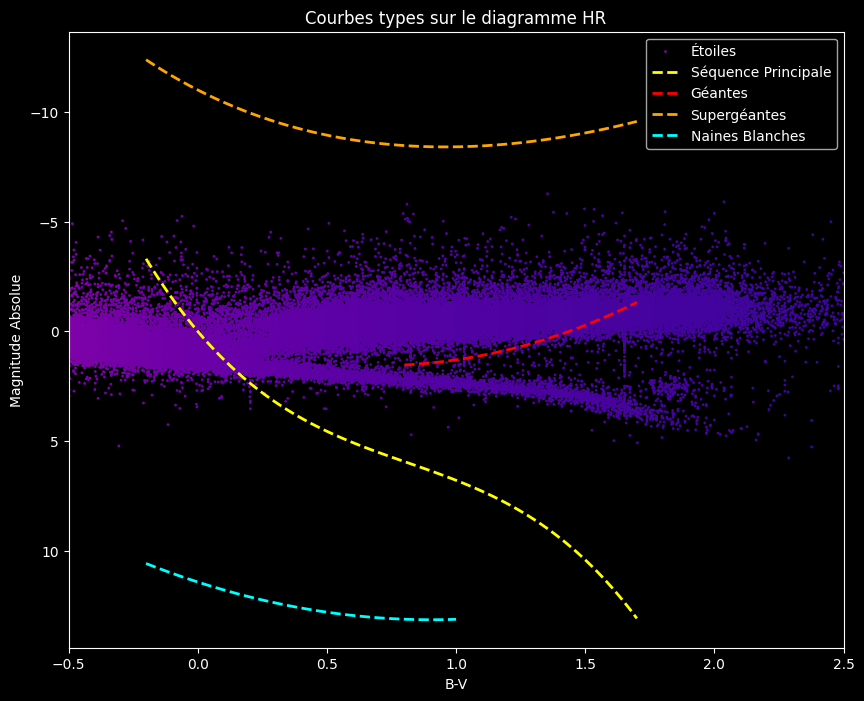

In [31]:
def mag_seq_princ(bv):
    return 4.95 * bv**3 - 12.07 * bv**2 + 13.91 * bv

def mag_geantes(bv):
    return -2.1 * bv**2.2 + 2.9 * bv + 0.5

def mag_supergiantes(bv):
    return -6 * np.exp(-bv) - 1.2 * bv**2 - 5

def mag_naines_blanches(bv):
    return -2.1 * (bv + 0.5)**2 + 5.9 * (bv + 0.5) + 9

bv_seq_princ = np.linspace(-0.2, 1.7, 100)
bv_geantes = np.linspace(0.8, 1.7, 100) 
bv_superg = np.linspace(-0.2, 1.7, 100) 
bv_naine_blanche = np.linspace(-0.2, 1.0, 100)

abs_mag_seq_princ = mag_seq_princ(bv_seq_princ)
abs_mag_geantes = mag_geantes(bv_geantes)
abs_mag_superg = mag_supergiantes(bv_superg)
abs_mag_naine_blanche = mag_naines_blanches(bv_naine_blanche)

# Tracer les courbes
plt.figure(figsize=(10, 8))
plt.scatter(X_scaled_df['B-V'], X_scaled_df['AbsoluteMag'], s=1, c=X_scaled_df['Temperature'], cmap="plasma", label='Étoiles')
plt.plot(bv_seq_princ, abs_mag_seq_princ, color='yellow', linestyle='--', linewidth=2, label='Séquence Principale')
plt.plot(bv_geantes, abs_mag_geantes, color='red', linestyle='--', linewidth=2, label='Géantes')
plt.plot(bv_superg, abs_mag_superg, color='orange', linestyle='--', linewidth=2, label='Supergéantes')
plt.plot(bv_naine_blanche, abs_mag_naine_blanche, color='cyan', linestyle='--', linewidth=2, label='Naines Blanches')
plt.gca().invert_yaxis()
plt.xlim(-0.5, 2.5)
plt.xlabel("B-V")
plt.ylabel("Magnitude Absolue")
plt.title("Courbes types sur le diagramme HR")
plt.legend()
plt.show()

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, criterion = "gini", max_features="sqrt", bootstrap=True, max_samples=2/3, oob_score=True)

In [29]:
rf.fit(X_scaled_df)

TypeError: BaseForest.fit() missing 1 required positional argument: 'y'